Train dataset size: 18900
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


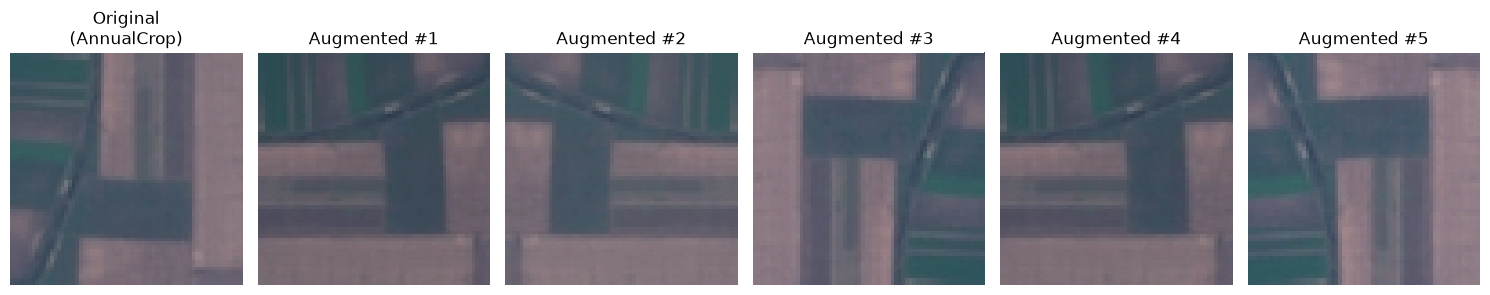

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from src.data.dataset import EuroSATDataset
from src.data.transforms import get_train_transforms, get_eval_transforms

train_ds = EuroSATDataset(split="train", transform=get_train_transforms())
eval_ds = EuroSATDataset(split="train", transform=get_eval_transforms())  # same images, no aug

print(f"Train dataset size: {len(train_ds)}")
print(f"Classes: {train_ds.classes}")

# Show the SAME underlying image, once augmented (5x) and once not, to visually
# confirm augmentation is doing something sensible and not distorting content
idx = 42

def denormalize(tensor, mean, std):
    import numpy as np
    arr = tensor.numpy().transpose(1, 2, 0)
    return np.clip(arr * np.array(std) + np.array(mean), 0, 1)

from src.data.transforms import load_normalization_stats
mean, std = load_normalization_stats()

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
img_eval, label = eval_ds[idx]
axes[0].imshow(denormalize(img_eval, mean, std))
axes[0].set_title(f"Original\n({eval_ds.classes[label]})")
axes[0].axis("off")

for i in range(1, 6):
    img_aug, _ = train_ds[idx]  # re-fetching re-applies random augmentation each time
    axes[i].imshow(denormalize(img_aug, mean, std))
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/augmentation_examples.png", dpi=150)
plt.show()